  PNEUMONIA DETECTION — KNN
  COVID-19 Radiography Database

  Pneumonia path : /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/images
  Normal path    : /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images
  Pneumonia exists: True
  Normal exists   : True

[1] LOADING IMAGES
-----------------------------------------------------------------

  ── Pneumonia (label=1) ──
  Found   1345 images → /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/images



  ── Normal (label=0) ──
  Found  10192 images → /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images



  Total     : 11537
  Normal    : 10192
  Pneumonia : 1345

[2] EXTRACTING FEATURES
-----------------------------------------------------------------


  Shape: (11537, 16388)

[3] SPLITTING DATASET  (70% Train | 15% Val | 15% Test)
-----------------------------------------------------------------
  Train :   8075  (Normal=7134, Pneumonia=941)
  Val   :   1731  (Normal=1529, Pneumonia=202)
  Test  :   1731  (Normal=1529, Pneumonia=202)
  ✓ Test set LOCKED until Step 10.

[4] STANDARDSCALER
-----------------------------------------------------------------
  ✓ Fit on Train only.

[5] PCA  (n_components=100)
-----------------------------------------------------------------
  Variance explained : 91.48%
  Reduced shape      : (8075, 100)

[6] K VALIDATION  (euclidean, uniform weights)
-----------------------------------------------------------------
  k       Accuracy  Precision   Recall  Specificity       F1      AUC
  ──────────────────────────────────────────────────────────────────
  k=3        0.9780     0.9059   0.9059       0.9876   0.9059   0.9781
  k=5        0.9780     0.8981   0.9158       0.9863   0.9069   0.9855
  k=7        

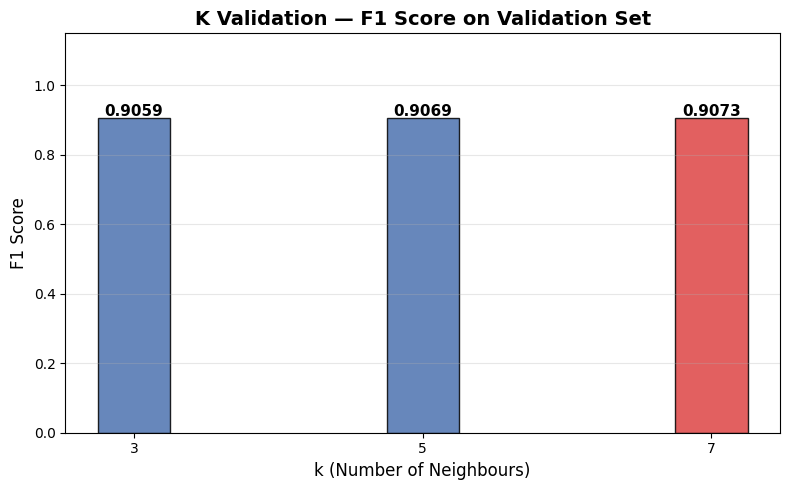

  ✓ k_validation.png

[7] TRAINING FINAL MODEL  (k=7)
-----------------------------------------------------------------
  ✓ Done.

[8] 5-FOLD CROSS VALIDATION  (Training Set)
-----------------------------------------------------------------

  Fold     Accuracy  Precision     Recall         F1
  ────────────────────────────────────────────────
  Fold 1       0.9759      0.8901      0.9043      0.8971
  Fold 2       0.9771      0.9037      0.8989      0.9013
  Fold 3       0.9814      0.8950      0.9521      0.9227
  Fold 4       0.9789      0.9185      0.8989      0.9086
  Fold 5       0.9740      0.8769      0.9048      0.8906
  ────────────────────────────────────────────────
  Mean         0.9775      0.8968      0.9118      0.9041
  Std          0.0026      0.0139      0.0203      0.0110


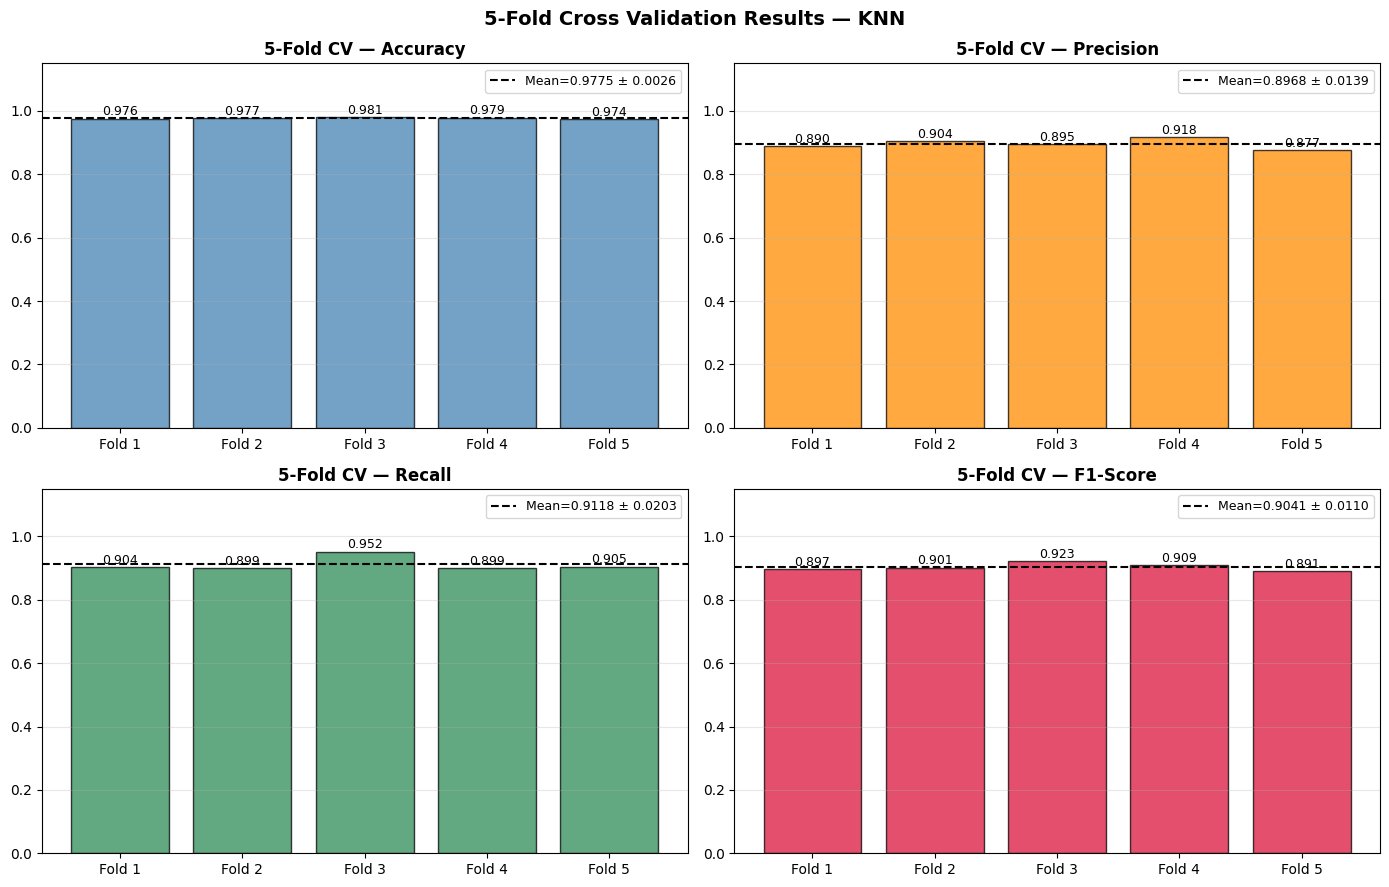

  ✓ cv_results.png

[9] VALIDATION SET EVALUATION
-----------------------------------------------------------------

  ── Validation Metrics  (k=7) ───────────────────────
  Metric                          Score         %
  ────────────────────────────────────────────────
  Accuracy                       0.9780    97.80%
  Precision                      0.8942    89.42%
  Recall (Sensitivity)           0.9208    92.08%
  Specificity                    0.9856    98.56%
  F1-Score                       0.9073    90.73%
  ROC-AUC                        0.9876    98.76%
  ────────────────────────────────────────────────
  TP=186  TN=1507  FP=22  FN=16

  Graphs:


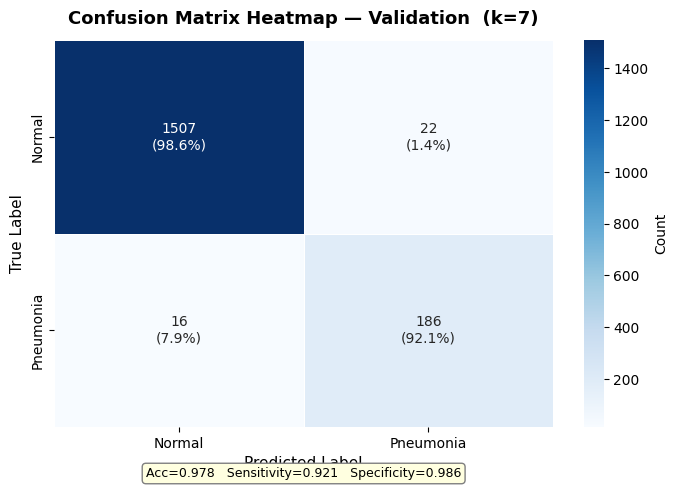

  ✓ cm_heatmap_validation.png


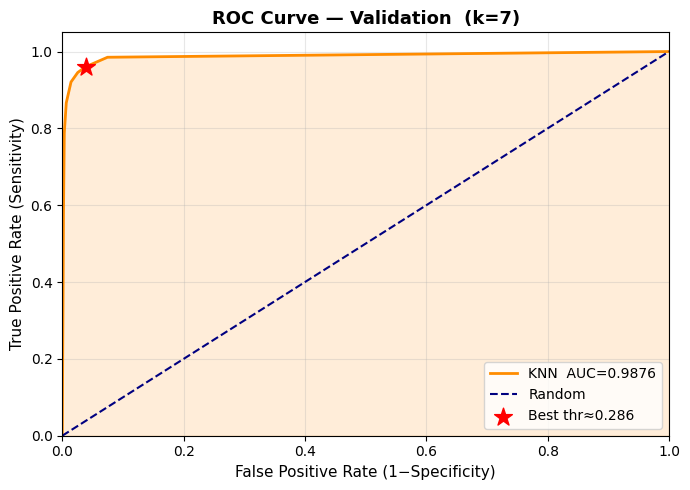

  ✓ roc_validation.png

[10] FINAL TEST SET EVALUATION
-----------------------------------------------------------------

  ── Test Metrics  (k=7) ─────────────────────────────
  Metric                          Score         %
  ────────────────────────────────────────────────
  Accuracy                       0.9717    97.17%
  Precision                      0.8696    86.96%
  Recall (Sensitivity)           0.8911    89.11%
  Specificity                    0.9823    98.23%
  F1-Score                       0.8802    88.02%
  ROC-AUC                        0.9904    99.04%
  ────────────────────────────────────────────────
  TP=180  TN=1502  FP=27  FN=22

  Graphs:


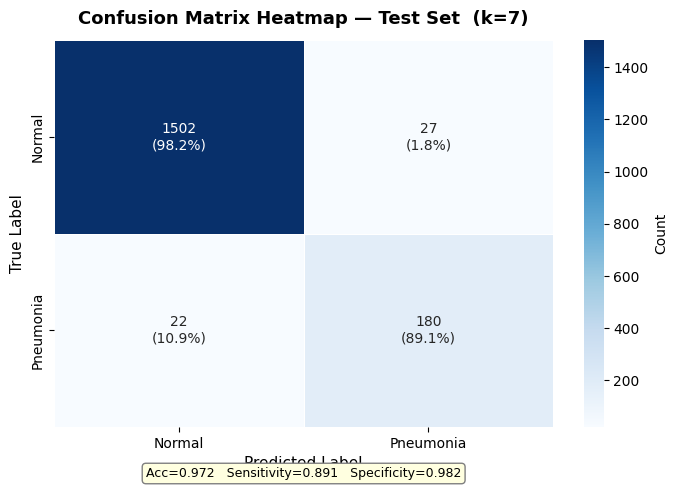

  ✓ cm_heatmap_test.png


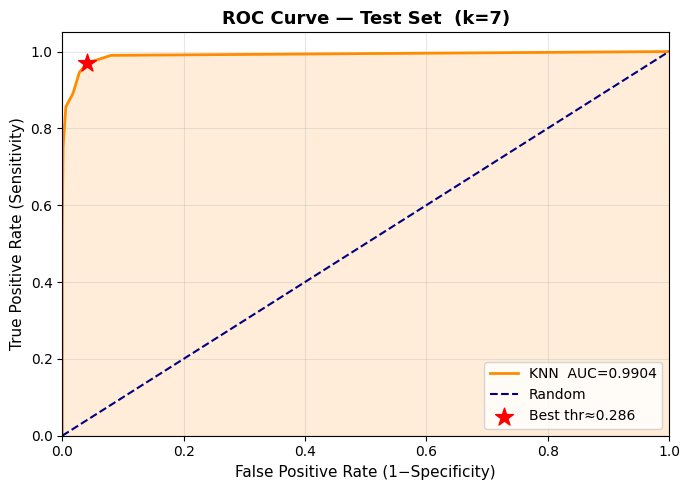

  ✓ roc_test.png


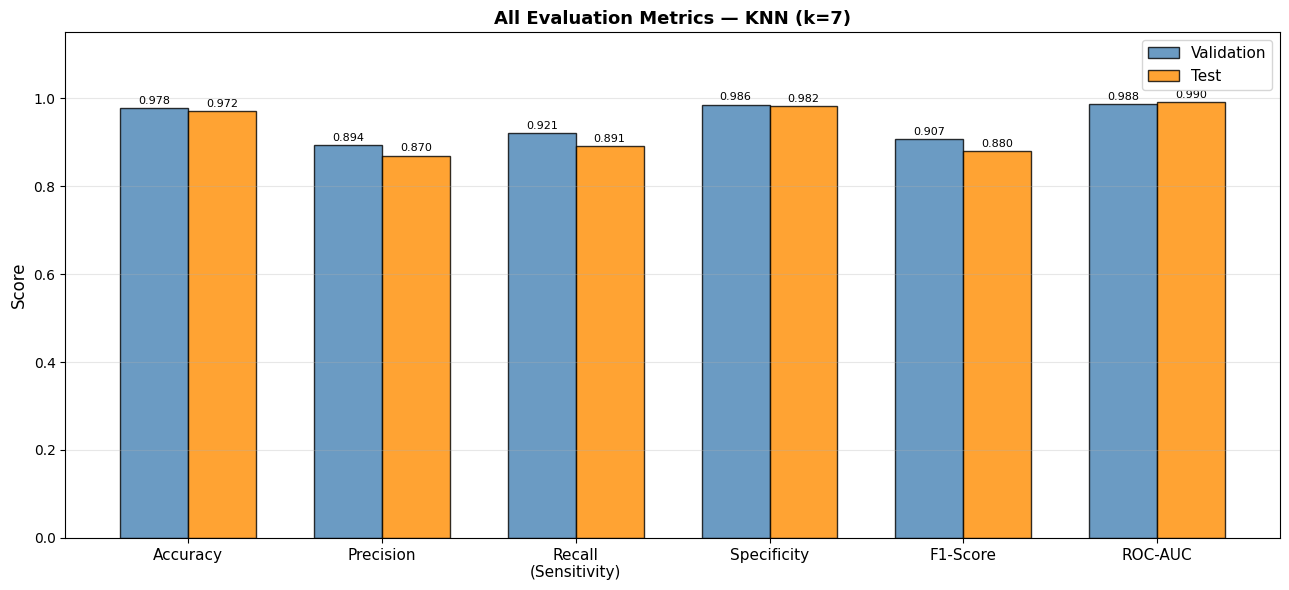

  ✓ metrics_summary.png

  Classification Report (Test Set):
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98      1529
   Pneumonia       0.87      0.89      0.88       202

    accuracy                           0.97      1731
   macro avg       0.93      0.94      0.93      1731
weighted avg       0.97      0.97      0.97      1731


[11] SAVING
-----------------------------------------------------------------
  ✓ Model pkl saved
  ✓ JSON results saved
  ✓ Text report saved

  Output files in /kaggle/working:
    cm_heatmap_test.png  (60.6 KB)
    cm_heatmap_validation.png  (59.2 KB)
    cv_results.png  (102.0 KB)
    k_validation.png  (36.0 KB)
    knn_model_20260224_162728.pkl  (10069.9 KB)
    knn_model_latest.pkl  (10069.9 KB)
    knn_report_20260224_162728.txt  (2.1 KB)
    knn_results_20260224_162728.json  (3.6 KB)
    metrics_summary.png  (58.2 KB)
    roc_test.png  (65.4 KB)
    roc_validation.png  (66.7 KB)

  FINAL SUMMARY


In [3]:
# ============================================================
# PNEUMONIA DETECTION USING KNN
# Dataset : COVID-19 Radiography Database (Kaggle)
# Classes : Viral Pneumonia (1) vs Normal (0)
# Split   : Train 70% | Validation 15% | Test 15%
# Metrics : Accuracy, Precision, Recall (Sensitivity),
#           Specificity, F1-Score, ROC-AUC
# Graphs  : Confusion Matrix Heatmap, ROC Curve
# ============================================================

import os, cv2, pickle, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datetime import datetime

from sklearn.neighbors       import KNeighborsClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate)
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score, roc_auc_score,
                                     roc_curve, confusion_matrix,
                                     classification_report)
warnings.filterwarnings('ignore')

# ============================================================
# PATHS  — hardcoded from dataset scan
# ============================================================
_BASE = ('/kaggle/input/datasets/tawsifurrahman/'
         'covid19-radiography-database/'
         'COVID-19_Radiography_Dataset')

PNEUMONIA_PATH = os.path.join(_BASE, 'Viral Pneumonia', 'images')
NORMAL_PATH    = os.path.join(_BASE, 'Normal', 'images')

# ============================================================
# CONFIGURATION
# ============================================================
IMG_SIZE      = (128, 128)
RANDOM_STATE  = 42
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
TEST_RATIO    = 0.15
N_COMPONENTS  = 100
K_VALUES      = [3, 5, 7]
FIXED_METRIC  = 'euclidean'
FIXED_WEIGHTS = 'uniform'
N_FOLDS       = 5
OUT           = '/kaggle/working'

print("="*65)
print("  PNEUMONIA DETECTION — KNN")
print("  COVID-19 Radiography Database")
print("="*65)
print(f"\n  Pneumonia path : {PNEUMONIA_PATH}")
print(f"  Normal path    : {NORMAL_PATH}")
print(f"  Pneumonia exists: {os.path.exists(PNEUMONIA_PATH)}")
print(f"  Normal exists   : {os.path.exists(NORMAL_PATH)}")

# ============================================================
# HELPERS
# ============================================================

def load_images(folder_path, label):
    images, labels = [], []
    files = [f for f in os.listdir(folder_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"  Found {len(files):>6} images → {folder_path}")
    for fname in tqdm(files, desc="  Loading", leave=False):
        try:
            img = cv2.imread(os.path.join(folder_path, fname),
                             cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, IMG_SIZE)
                images.append(img)
                labels.append(label)
        except Exception:
            pass
    return images, labels


def extract_features(images):
    out = []
    for img in tqdm(images, desc="  Features", leave=False):
        flat  = img.flatten().astype(np.float32)
        stats = np.array([img.mean(), img.std(),
                          img.min(),  img.max()], dtype=np.float32)
        out.append(np.concatenate([flat, stats]))
    return np.array(out)


def split_data(X, y):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=(VAL_RATIO + TEST_RATIO),
        stratify=y, random_state=RANDOM_STATE)
    X_v, X_te, y_v, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.5,
        stratify=y_tmp, random_state=RANDOM_STATE)
    return X_tr, X_v, X_te, y_tr, y_v, y_te


def metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return dict(
        accuracy           = float(accuracy_score(y_true, y_pred)),
        precision          = float(precision_score(y_true, y_pred, zero_division=0)),
        recall_sensitivity = float(recall_score(y_true, y_pred, zero_division=0)),
        specificity        = float(tn / (tn + fp)) if (tn+fp) else 0.0,
        f1_score           = float(f1_score(y_true, y_pred, zero_division=0)),
        roc_auc            = float(roc_auc_score(y_true, y_prob)),
        tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))


def print_table(m, title=""):
    print(f"\n  ── {title} {'─'*(48-len(title))}")
    print(f"  {'Metric':<28} {'Score':>8}   {'%':>7}")
    print(f"  {'─'*48}")
    for name, key in [('Accuracy',             'accuracy'),
                       ('Precision',            'precision'),
                       ('Recall (Sensitivity)', 'recall_sensitivity'),
                       ('Specificity',          'specificity'),
                       ('F1-Score',             'f1_score'),
                       ('ROC-AUC',              'roc_auc')]:
        v = m[key]
        print(f"  {name:<28} {v:>8.4f}   {v*100:>6.2f}%")
    print(f"  {'─'*48}")
    print(f"  TP={m['tp']}  TN={m['tn']}  FP={m['fp']}  FN={m['fn']}")


# ── Plots ────────────────────────────────────────────────────

def plot_cm(y_true, y_pred, title, fname):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot  = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)"
                        for j in range(2)] for i in range(2)])
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                linewidths=0.5, linecolor='white', ax=ax,
                xticklabels=['Normal','Pneumonia'],
                yticklabels=['Normal','Pneumonia'],
                cbar_kws={'label':'Count'})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    tn, fp, fn, tp = cm.ravel()
    acc  = (tp+tn)/(tp+tn+fp+fn)
    sens = tp/(tp+fn) if (tp+fn) else 0
    spec = tn/(tn+fp) if (tn+fp) else 0
    ax.text(0.5, -0.13,
            f"Acc={acc:.3f}   Sensitivity={sens:.3f}   Specificity={spec:.3f}",
            transform=ax.transAxes, ha='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✓ {fname}")


def plot_roc(y_true, y_prob, title, fname):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    auc     = roc_auc_score(y_true, y_prob)
    best_ix = np.argmin(np.sqrt(fpr**2 + (1-tpr)**2))
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.fill_between(fpr, tpr, alpha=0.15, color='darkorange')
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'KNN  AUC={auc:.4f}')
    ax.plot([0,1],[0,1], 'navy', lw=1.5, linestyle='--', label='Random')
    ax.scatter(fpr[best_ix], tpr[best_ix], marker='*', s=180,
               color='red', zorder=5,
               label=f'Best thr≈{thr[best_ix]:.3f}')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.set_xlabel('False Positive Rate (1−Specificity)', fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity)',    fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✓ {fname}")


def plot_k_val(k_values, f1s):
    colors = ['#DD4444' if f == max(f1s) else '#4C72B0' for f in f1s]
    fig, ax = plt.subplots(figsize=(8,5))
    bars = ax.bar(k_values, f1s, color=colors, width=0.5,
                  edgecolor='black', alpha=0.85)
    for b, s in zip(bars, f1s):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f'{s:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title('K Validation — F1 Score on Validation Set',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('k (Number of Neighbours)', fontsize=12)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_xticks(k_values); ax.set_ylim([0,1.15])
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT,'k_validation.png'), dpi=150)
    plt.show(); print("  ✓ k_validation.png")


def plot_cv(cv_res):
    metrics_list = ['accuracy','precision','recall','f1']
    labels       = ['Accuracy','Precision','Recall','F1-Score']
    colors       = ['steelblue','darkorange','seagreen','crimson']
    folds        = [f'Fold {i+1}' for i in range(N_FOLDS)]
    fig, axes = plt.subplots(2, 2, figsize=(14,9))
    for ax, met, lab, col in zip(axes.ravel(), metrics_list, labels, colors):
        sc = cv_res[f'test_{met}']
        ax.bar(folds, sc, color=col, alpha=0.75, edgecolor='black')
        ax.axhline(sc.mean(), color='black', linestyle='--', lw=1.5,
                   label=f'Mean={sc.mean():.4f} ± {sc.std():.4f}')
        for i,v in enumerate(sc):
            ax.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)
        ax.set_title(f'5-Fold CV — {lab}', fontsize=12, fontweight='bold')
        ax.set_ylim([0,1.15]); ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3)
    plt.suptitle('5-Fold Cross Validation Results — KNN',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT,'cv_results.png'), dpi=150)
    plt.show(); print("  ✓ cv_results.png")


def plot_summary(val_m, test_m, best_k):
    names = ['Accuracy','Precision','Recall\n(Sensitivity)',
             'Specificity','F1-Score','ROC-AUC']
    keys  = ['accuracy','precision','recall_sensitivity',
             'specificity','f1_score','roc_auc']
    vv = [val_m[k]  for k in keys]
    tv = [test_m[k] for k in keys]
    x = np.arange(len(names)); w = 0.35
    fig, ax = plt.subplots(figsize=(13,6))
    b1 = ax.bar(x-w/2, vv, w, label='Validation',
                color='steelblue',  alpha=0.8, edgecolor='black')
    b2 = ax.bar(x+w/2, tv, w, label='Test',
                color='darkorange', alpha=0.8, edgecolor='black')
    for b in list(b1)+list(b2):
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h+0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
    ax.set_ylim([0,1.15]); ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'All Evaluation Metrics — KNN (k={best_k})',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT,'metrics_summary.png'), dpi=150)
    plt.show(); print("  ✓ metrics_summary.png")


# ============================================================
# STEP 1 — LOAD IMAGES
# ============================================================
print("\n[1] LOADING IMAGES")
print("-"*65)

all_images, all_labels = [], []

print("\n  ── Pneumonia (label=1) ──")
imgs, lbls = load_images(PNEUMONIA_PATH, label=1)
all_images.extend(imgs); all_labels.extend(lbls)

print("\n  ── Normal (label=0) ──")
imgs, lbls = load_images(NORMAL_PATH, label=0)
all_images.extend(imgs); all_labels.extend(lbls)

print(f"\n  Total     : {len(all_images)}")
print(f"  Normal    : {all_labels.count(0)}")
print(f"  Pneumonia : {all_labels.count(1)}")

if len(set(all_labels)) < 2:
    raise RuntimeError("Only one class loaded — check paths above.")

# ============================================================
# STEP 2 — FEATURE EXTRACTION
# ============================================================
print("\n[2] EXTRACTING FEATURES")
print("-"*65)
X = extract_features(all_images)
y = np.array(all_labels)
print(f"  Shape: {X.shape}")

# ============================================================
# STEP 3 — SPLIT  (70 / 15 / 15)
# ============================================================
print("\n[3] SPLITTING DATASET  (70% Train | 15% Val | 15% Test)")
print("-"*65)
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
print(f"  Train : {len(X_train):>6}  "
      f"(Normal={sum(y_train==0)}, Pneumonia={sum(y_train==1)})")
print(f"  Val   : {len(X_val):>6}  "
      f"(Normal={sum(y_val==0)}, Pneumonia={sum(y_val==1)})")
print(f"  Test  : {len(X_test):>6}  "
      f"(Normal={sum(y_test==0)}, Pneumonia={sum(y_test==1)})")
print("  ✓ Test set LOCKED until Step 10.")

# ============================================================
# STEP 4 — STANDARDSCALER
# ============================================================
print("\n[4] STANDARDSCALER")
print("-"*65)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_val_sc    = scaler.transform(X_val)
X_test_sc   = scaler.transform(X_test)
print("  ✓ Fit on Train only.")

# ============================================================
# STEP 5 — PCA
# ============================================================
print(f"\n[5] PCA  (n_components={N_COMPONENTS})")
print("-"*65)
pca         = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca   = pca.transform(X_val_sc)
X_test_pca  = pca.transform(X_test_sc)
print(f"  Variance explained : {sum(pca.explained_variance_ratio_)*100:.2f}%")
print(f"  Reduced shape      : {X_train_pca.shape}")

# ============================================================
# STEP 6 — K VALIDATION  (k = 3, 5, 7)
# ============================================================
print("\n[6] K VALIDATION  (euclidean, uniform weights)")
print("-"*65)
print(f"  {'k':<5} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} "
      f"{'Specificity':>12} {'F1':>8} {'AUC':>8}")
print("  " + "─"*66)

val_scores  = {}
val_metrics_dict = {}

for k in K_VALUES:
    mdl  = KNeighborsClassifier(n_neighbors=k,
                                 metric=FIXED_METRIC,
                                 weights=FIXED_WEIGHTS)
    mdl.fit(X_train_pca, y_train)
    yp   = mdl.predict(X_val_pca)
    prob = mdl.predict_proba(X_val_pca)
    yprb = prob[:, 1] if prob.shape[1] == 2 else prob[:, 0]
    m    = metrics(y_val, yp, yprb)
    val_scores[k]       = m['f1_score']
    val_metrics_dict[k] = m
    print(f"  k={k:<3}  "
          f"{m['accuracy']:>10.4f} {m['precision']:>10.4f} "
          f"{m['recall_sensitivity']:>8.4f} {m['specificity']:>12.4f} "
          f"{m['f1_score']:>8.4f} {m['roc_auc']:>8.4f}")

best_k = max(val_scores, key=val_scores.get)
print(f"\n  ✓ Best k = {best_k}  (Val F1 = {val_scores[best_k]:.4f})")
plot_k_val(K_VALUES, [val_scores[k] for k in K_VALUES])

# ============================================================
# STEP 7 — TRAIN FINAL MODEL
# ============================================================
print(f"\n[7] TRAINING FINAL MODEL  (k={best_k})")
print("-"*65)
knn = KNeighborsClassifier(n_neighbors=best_k,
                            metric=FIXED_METRIC,
                            weights=FIXED_WEIGHTS)
knn.fit(X_train_pca, y_train)
print("  ✓ Done.")

# ============================================================
# STEP 8 — 5-FOLD CROSS VALIDATION
# ============================================================
print(f"\n[8] 5-FOLD CROSS VALIDATION  (Training Set)")
print("-"*65)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                       random_state=RANDOM_STATE)
cv_res = cross_validate(
    knn, X_train_pca, y_train, cv=skf,
    scoring={'accuracy':'accuracy','precision':'precision',
             'recall':'recall','f1':'f1'},
    return_train_score=False, n_jobs=-1)

print(f"\n  {'Fold':<6} {'Accuracy':>10} {'Precision':>10} "
      f"{'Recall':>10} {'F1':>10}")
print("  " + "─"*48)
for i in range(N_FOLDS):
    print(f"  Fold {i+1}   "
          f"{cv_res['test_accuracy'][i]:>10.4f}  "
          f"{cv_res['test_precision'][i]:>10.4f}  "
          f"{cv_res['test_recall'][i]:>10.4f}  "
          f"{cv_res['test_f1'][i]:>10.4f}")
print("  " + "─"*48)
print(f"  Mean     "
      f"{cv_res['test_accuracy'].mean():>10.4f}  "
      f"{cv_res['test_precision'].mean():>10.4f}  "
      f"{cv_res['test_recall'].mean():>10.4f}  "
      f"{cv_res['test_f1'].mean():>10.4f}")
print(f"  Std      "
      f"{cv_res['test_accuracy'].std():>10.4f}  "
      f"{cv_res['test_precision'].std():>10.4f}  "
      f"{cv_res['test_recall'].std():>10.4f}  "
      f"{cv_res['test_f1'].std():>10.4f}")
plot_cv(cv_res)

# ============================================================
# STEP 9 — VALIDATION SET EVALUATION
# ============================================================
print("\n[9] VALIDATION SET EVALUATION")
print("-"*65)
y_val_pred = knn.predict(X_val_pca)
y_val_prob = knn.predict_proba(X_val_pca)[:, 1]
val_m      = metrics(y_val, y_val_pred, y_val_prob)
print_table(val_m, f"Validation Metrics  (k={best_k})")

print("\n  Graphs:")
plot_cm(y_val, y_val_pred,
        f'Confusion Matrix Heatmap — Validation  (k={best_k})',
        'cm_heatmap_validation.png')
plot_roc(y_val, y_val_prob,
         f'ROC Curve — Validation  (k={best_k})',
         'roc_validation.png')

# ============================================================
# STEP 10 — FINAL TEST EVALUATION  (test set unlocked)
# ============================================================
print("\n[10] FINAL TEST SET EVALUATION")
print("-"*65)
y_test_pred = knn.predict(X_test_pca)
y_test_prob = knn.predict_proba(X_test_pca)[:, 1]
test_m      = metrics(y_test, y_test_pred, y_test_prob)
print_table(test_m, f"Test Metrics  (k={best_k})")

print("\n  Graphs:")
plot_cm(y_test, y_test_pred,
        f'Confusion Matrix Heatmap — Test Set  (k={best_k})',
        'cm_heatmap_test.png')
plot_roc(y_test, y_test_prob,
         f'ROC Curve — Test Set  (k={best_k})',
         'roc_test.png')
plot_summary(val_m, test_m, best_k)

print("\n  Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred,
                             target_names=['Normal','Pneumonia']))

# ============================================================
# STEP 11 — SAVE
# ============================================================
print("\n[11] SAVING")
print("-"*65)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

model_pkg = dict(knn_model=knn, scaler=scaler, pca=pca,
                 img_size=IMG_SIZE, n_components=N_COMPONENTS,
                 best_k=best_k, metric=FIXED_METRIC,
                 weights=FIXED_WEIGHTS, training_date=ts)
for p in [f'{OUT}/knn_model_{ts}.pkl', f'{OUT}/knn_model_latest.pkl']:
    with open(p,'wb') as f: pickle.dump(model_pkg, f)
print("  ✓ Model pkl saved")

results_json = {
    'timestamp'   : ts,
    'model'       : f'KNN k={best_k} | {FIXED_METRIC} | {FIXED_WEIGHTS}',
    'split'       : {'train':TRAIN_RATIO,'val':VAL_RATIO,'test':TEST_RATIO},
    'pca_variance': float(sum(pca.explained_variance_ratio_)),
    'k_validation': {str(k): val_metrics_dict[k] for k in K_VALUES},
    'best_k'      : best_k,
    'cv_5fold'    : {
        'mean_accuracy' : float(cv_res['test_accuracy'].mean()),
        'std_accuracy'  : float(cv_res['test_accuracy'].std()),
        'mean_precision': float(cv_res['test_precision'].mean()),
        'std_precision' : float(cv_res['test_precision'].std()),
        'mean_recall'   : float(cv_res['test_recall'].mean()),
        'std_recall'    : float(cv_res['test_recall'].std()),
        'mean_f1'       : float(cv_res['test_f1'].mean()),
        'std_f1'        : float(cv_res['test_f1'].std()),
        'per_fold'      : [{
            'fold'     : i+1,
            'accuracy' : float(cv_res['test_accuracy'][i]),
            'precision': float(cv_res['test_precision'][i]),
            'recall'   : float(cv_res['test_recall'][i]),
            'f1'       : float(cv_res['test_f1'][i]),
        } for i in range(N_FOLDS)]
    },
    'validation_metrics': val_m,
    'test_metrics'      : test_m,
}
with open(f'{OUT}/knn_results_{ts}.json','w') as f:
    json.dump(results_json, f, indent=4)
print("  ✓ JSON results saved")

with open(f'{OUT}/knn_report_{ts}.txt','w') as f:
    f.write("="*65+"\n  PNEUMONIA DETECTION — KNN REPORT\n"+"="*65+"\n\n")
    f.write(f"Date  : {ts}\n")
    f.write(f"Model : KNN k={best_k} | {FIXED_METRIC} | {FIXED_WEIGHTS}\n")
    f.write(f"Split : Train 70% | Val 15% | Test 15%\n\n")
    f.write("K VALIDATION\n"+"─"*40+"\n")
    for k in K_VALUES:
        m   = val_metrics_dict[k]
        tag = "  ← BEST" if k == best_k else ""
        f.write(f"  k={k}  Acc={m['accuracy']:.4f}  Prec={m['precision']:.4f}  "
                f"Rec={m['recall_sensitivity']:.4f}  Spec={m['specificity']:.4f}  "
                f"F1={m['f1_score']:.4f}  AUC={m['roc_auc']:.4f}{tag}\n")
    f.write("\n5-FOLD CV (Training Set)\n"+"─"*40+"\n")
    for i in range(N_FOLDS):
        f.write(f"  Fold {i+1}  Acc={cv_res['test_accuracy'][i]:.4f}  "
                f"Prec={cv_res['test_precision'][i]:.4f}  "
                f"Rec={cv_res['test_recall'][i]:.4f}  "
                f"F1={cv_res['test_f1'][i]:.4f}\n")
    f.write(f"  Mean   Acc={cv_res['test_accuracy'].mean():.4f}  "
            f"F1={cv_res['test_f1'].mean():.4f}\n\n")
    for section, m in [("VALIDATION", val_m), ("TEST", test_m)]:
        f.write(f"{section} METRICS\n"+"─"*40+"\n")
        for key, val in m.items():
            f.write(f"  {key:<22}: {val}\n")
        f.write("\n")
print("  ✓ Text report saved")

print("\n  Output files in /kaggle/working:")
for fname in sorted(os.listdir(OUT)):
    fp = os.path.join(OUT, fname)
    if os.path.isfile(fp):
        print(f"    {fname}  ({os.path.getsize(fp)/1024:.1f} KB)")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n"+"="*65)
print("  FINAL SUMMARY")
print("="*65)
print(f"  Model  : KNN | k={best_k} | {FIXED_METRIC} | {FIXED_WEIGHTS}")
print(f"  Scaler : StandardScaler  |  PCA: {N_COMPONENTS} components\n")

print("  ┌─ K Validation ──────────────────────────────────────┐")
for k in K_VALUES:
    tag = "  ◄ BEST" if k == best_k else ""
    print(f"  │  k={k}  F1={val_scores[k]:.4f}{tag}")
print("  └─────────────────────────────────────────────────────┘\n")

print("  ┌─ 5-Fold CV Mean (Train) ────────────────────────────┐")
for met in ['accuracy','precision','recall','f1']:
    v = cv_res[f'test_{met}']
    print(f"  │  {met.capitalize():<12}: {v.mean():.4f} ± {v.std():.4f}")
print("  └─────────────────────────────────────────────────────┘\n")

print("  ┌─ Test Set Evaluation ───────────────────────────────┐")
for name, key in [('Accuracy',             'accuracy'),
                   ('Precision',            'precision'),
                   ('Recall (Sensitivity)', 'recall_sensitivity'),
                   ('Specificity',          'specificity'),
                   ('F1-Score',             'f1_score'),
                   ('ROC-AUC',              'roc_auc')]:
    v = test_m[key]
    print(f"  │  {name:<25} {v:.4f}  ({v*100:.2f}%)")
print("  └─────────────────────────────────────────────────────┘\n")

print("  Saved graphs:")
for g in ['k_validation.png','cv_results.png',
          'cm_heatmap_validation.png','roc_validation.png',
          'cm_heatmap_test.png','roc_test.png','metrics_summary.png']:
    print(f"    ✓ {g}")
print("\n  ✓ PIPELINE COMPLETE")
print("="*65)